#  Airplane Crashes and Fatalities Analysis (1908–2023)

**Objectif :** Analyser les données historiques sur les crashs aériens en utilisant Python, Pandas, NumPy, SciPy et les outils de visualisation.

**Dataset :** 4 998 crashs documentés, couvrant plus d'un siècle d'aviation.

---

## 1. Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white'
})

print('Bibliothèques chargées avec succès.')

Bibliothèques chargées avec succès.


## 2. Import et Nettoyage des Données

In [2]:
# --- Chargement ---
df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', encoding='latin1')
print(f'Shape initiale : {df.shape}')
df.head(3)

Shape initiale : (4998, 17)


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...


In [3]:
# --- Valeurs manquantes ---
missing = df.isnull().sum().rename('Missing').to_frame()
missing['%'] = (missing['Missing'] / len(df) * 100).round(1)
print(missing[missing['Missing'] > 0].to_string())

                       Missing     %
Time                      1512  30.3
Location                     4   0.1
Operator                    10   0.2
Flight #                  3669  73.4
Route                      777  15.5
AC Type                     15   0.3
Registration               274   5.5
cn/ln                      668  13.4
Aboard                      18   0.4
Aboard Passangers          229   4.6
Aboard Crew                226   4.5
Fatalities                   8   0.2
Fatalities Passangers      242   4.8
Fatalities Crew            241   4.8
Ground                      42   0.8
Summary                     64   1.3


In [4]:
# --- Nettoyage ---

# Conversion de la date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Extraction de l'année et de la décennie
df['Year']   = df['Date'].dt.year
df['Decade'] = (df['Year'] // 10 * 10).astype('Int64')

# Remplissage des valeurs numériques manquantes par la médiane
num_cols = ['Aboard', 'Aboard Passangers', 'Aboard Crew',
            'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# Taux de survie (0 si Aboard == 0)
df['Survivors']     = (df['Aboard'] - df['Fatalities']).clip(lower=0)
df['Survival_Rate'] = np.where(df['Aboard'] > 0, df['Survivors'] / df['Aboard'], np.nan)

# Nettoyage des textes
df['Operator'] = df['Operator'].fillna('Unknown').str.strip()
df['Location'] = df['Location'].fillna('Unknown').str.strip()

# Extraction du pays (dernier token après virgule)
df['Country'] = df['Location'].str.split(',').str[-1].str.strip()

print(f'Shape après nettoyage : {df.shape}')
df[['Date','Year','Decade','Aboard','Fatalities','Survivors','Survival_Rate']].head()

Shape après nettoyage : (4998, 22)


,Date,Year,Decade,Aboard,Fatalities,Survivors,Survival_Rate
0,1908-09-17,1908,1900,2.0,1.0,1.0,0.5
1,1909-09-07,1909,1900,1.0,1.0,0.0,0.0
2,1912-07-12,1912,1910,5.0,5.0,0.0,0.0
3,1913-08-06,1913,1910,1.0,1.0,0.0,0.0
4,1913-09-09,1913,1910,20.0,14.0,6.0,0.3


## 3. Analyse Exploratoire (EDA)

In [5]:
# --- Statistiques générales ---
total_crashes    = len(df)
total_fatalities = int(df['Fatalities'].sum())
total_aboard     = int(df['Aboard'].sum())
avg_survival     = df['Survival_Rate'].mean()
median_fat       = df['Fatalities'].median()

print('='*45)
print(f'  Total crashs enregistrés  : {total_crashes:,}')
print(f'  Total personnes à bord    : {total_aboard:,}')
print(f'  Total décès               : {total_fatalities:,}')
print(f'  Taux de survie moyen      : {avg_survival:.1%}')
print(f'  Médiane décès / crash     : {median_fat:.0f}')
print('='*45)

  Total crashs enregistrés  : 4,998
  Total personnes à bord    : 155,644
  Total décès               : 111,732
  Taux de survie moyen      : 18.2%
  Médiane décès / crash     : 11


In [6]:
# --- Statistiques descriptives détaillées ---
df[['Aboard','Fatalities','Survivors','Survival_Rate','Ground']].describe().round(2)

,Aboard,Fatalities,Survivors,Survival_Rate,Ground
count,4998.00,4998.00,4998.00,4993.00,4998.00
mean,31.14,22.36,8.79,0.18,1.70
std,45.46,35.04,30.60,0.31,55.31
min,0.00,0.00,0.00,0.00,0.00
25%,7.00,4.00,0.00,0.00,0.00
50%,16.00,11.00,0.00,0.00,0.00
75%,35.00,25.00,4.00,0.25,0.00
max,644.00,583.00,516.00,1.00,2750.00


### 3.1 Évolution des crashs par année

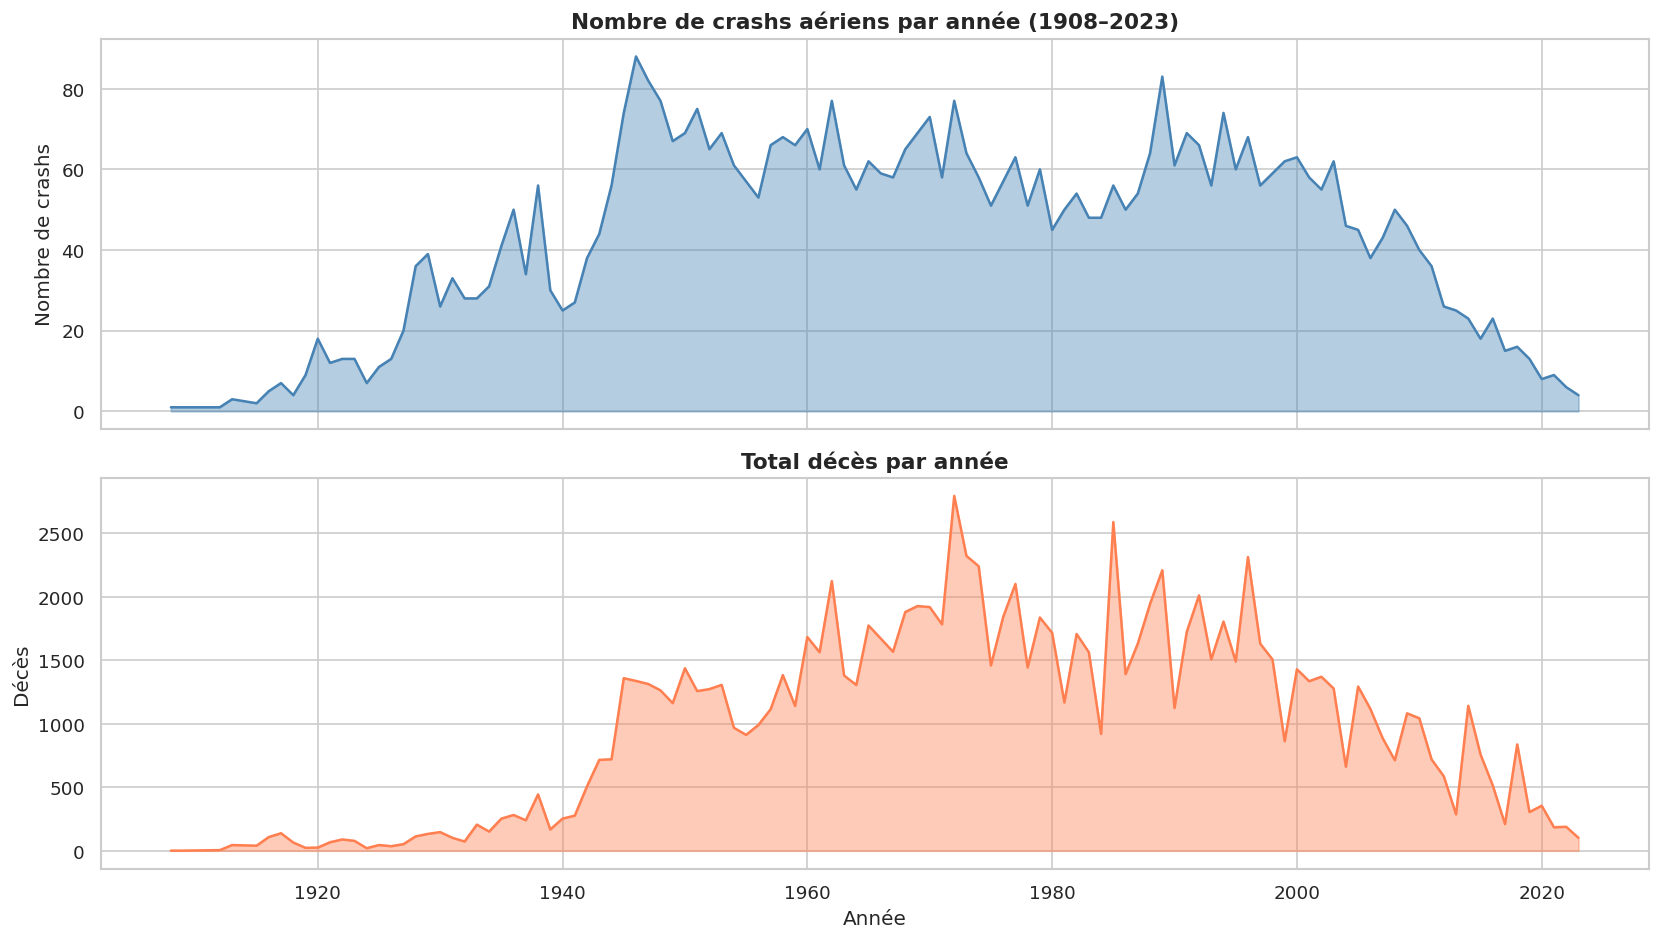

In [7]:
crashes_per_year  = df.groupby('Year').size()
fatalities_per_year = df.groupby('Year')['Fatalities'].sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].fill_between(crashes_per_year.index, crashes_per_year.values,
                     alpha=0.4, color='steelblue')
axes[0].plot(crashes_per_year.index, crashes_per_year.values, color='steelblue', lw=1.5)
axes[0].set_title('Nombre de crashs aériens par année (1908–2023)')
axes[0].set_ylabel('Nombre de crashs')

axes[1].fill_between(fatalities_per_year.index, fatalities_per_year.values,
                     alpha=0.4, color='coral')
axes[1].plot(fatalities_per_year.index, fatalities_per_year.values, color='coral', lw=1.5)
axes[1].set_title('Total décès par année')
axes[1].set_ylabel('Décès')
axes[1].set_xlabel('Année')

plt.tight_layout()
plt.savefig('/home/claude/fig1_crashes_per_year.png', bbox_inches='tight')
plt.show()

### 3.2 Taux de survie moyen par décennie

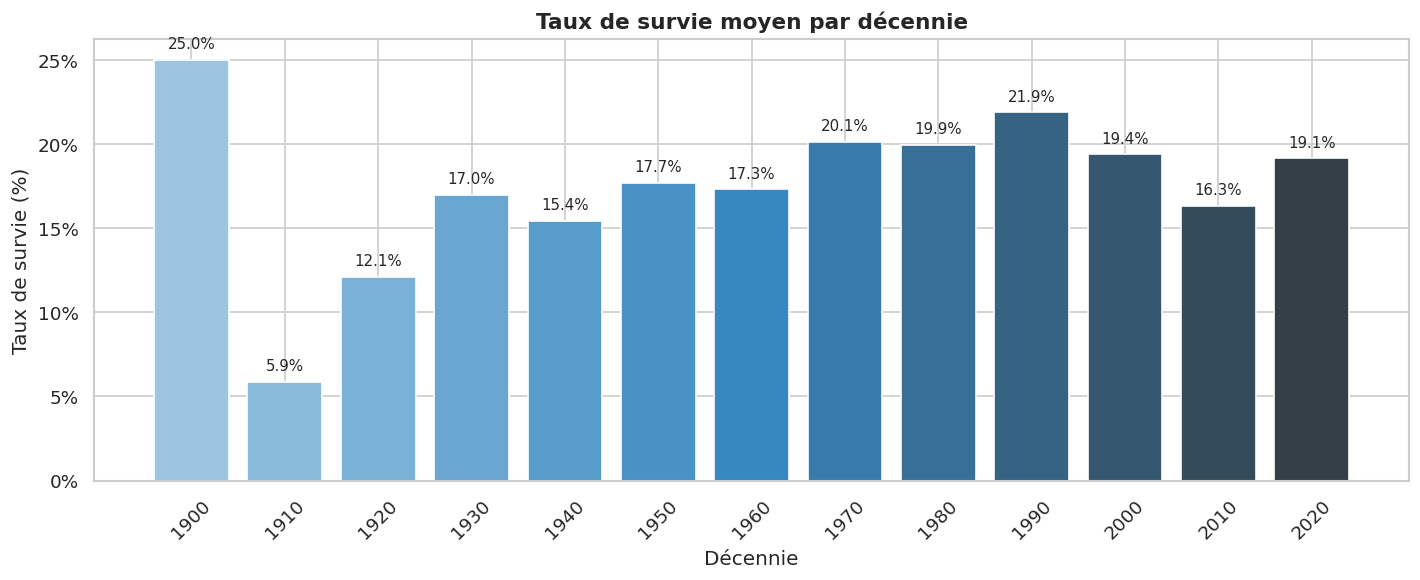

In [8]:
survival_decade = df.groupby('Decade')['Survival_Rate'].mean().dropna()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(survival_decade.index.astype(str), survival_decade.values * 100,
              color=sns.color_palette('Blues_d', len(survival_decade)), edgecolor='white')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Taux de survie moyen par décennie')
ax.set_xlabel('Décennie')
ax.set_ylabel('Taux de survie (%)')
plt.xticks(rotation=45)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/home/claude/fig2_survival_by_decade.png', bbox_inches='tight')
plt.show()

### 3.3 Top 15 opérateurs par nombre de crashs

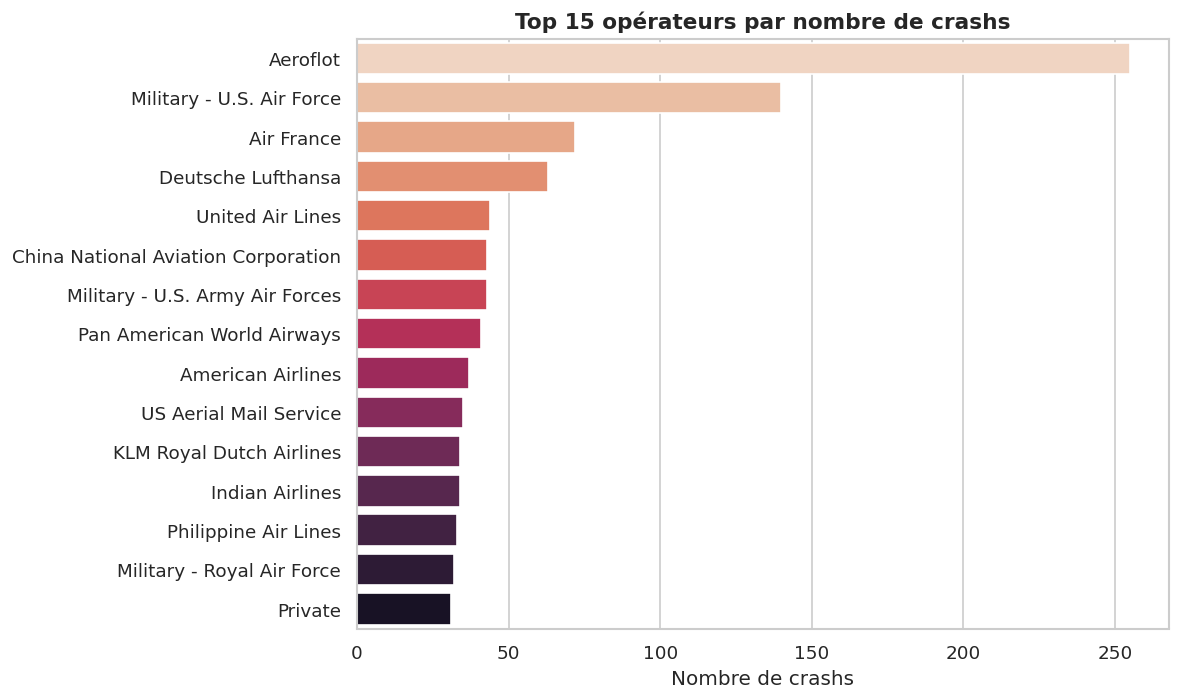

In [9]:
# Exclure les opérateurs génériques ou militaires flous
top_operators = (df['Operator']
                 .value_counts()
                 .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_operators.values, y=top_operators.index,
            palette='rocket_r', ax=ax)
ax.set_title('Top 15 opérateurs par nombre de crashs')
ax.set_xlabel('Nombre de crashs')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('/home/claude/fig3_top_operators.png', bbox_inches='tight')
plt.show()

### 3.4 Distribution des décès

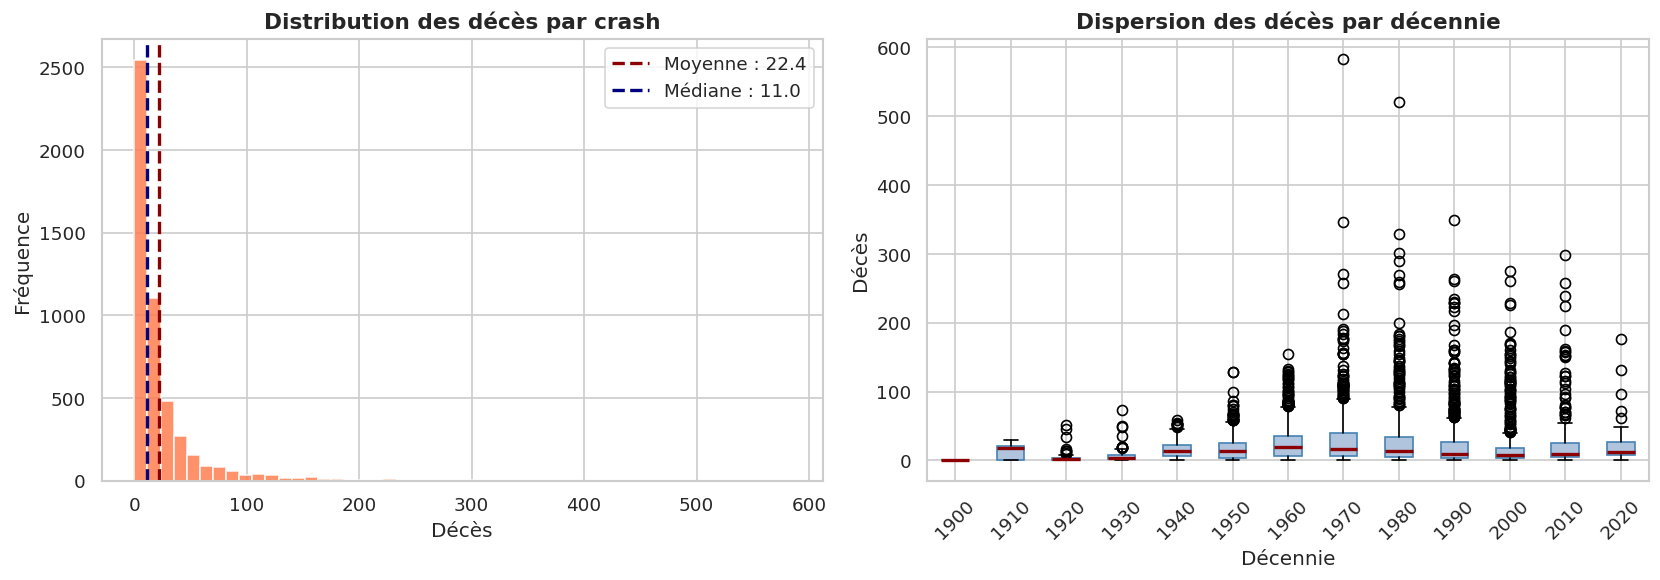

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['Fatalities'], bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Fatalities'].mean(),   color='darkred',  lw=2, ls='--', label=f"Moyenne : {df['Fatalities'].mean():.1f}")
axes[0].axvline(df['Fatalities'].median(), color='navy', lw=2, ls='--', label=f"Médiane : {df['Fatalities'].median():.1f}")
axes[0].set_title('Distribution des décès par crash')
axes[0].set_xlabel('Décès')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Boxplot par décennie
data_box = df[df['Decade'].notna()]
decade_labels = sorted(data_box['Decade'].unique())
box_data = [data_box[data_box['Decade'] == d]['Fatalities'].values for d in decade_labels]
axes[1].boxplot(box_data, labels=[str(int(d)) for d in decade_labels],
                patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
                medianprops=dict(color='darkred', lw=2))
axes[1].set_title('Dispersion des décès par décennie')
axes[1].set_xlabel('Décennie')
axes[1].set_ylabel('Décès')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('/home/claude/fig4_fatalities_dist.png', bbox_inches='tight')
plt.show()

### 3.5 Top 15 pays par nombre de crashs

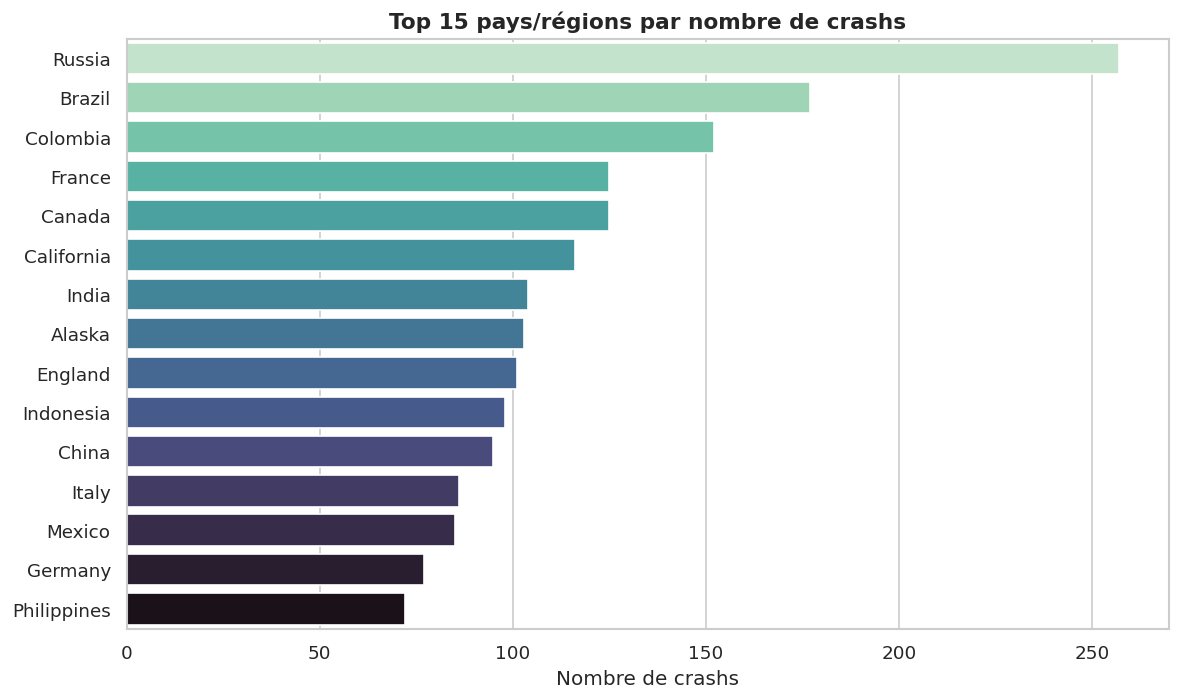

In [11]:
top_countries = df['Country'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index,
            palette='mako_r', ax=ax)
ax.set_title('Top 15 pays/régions par nombre de crashs')
ax.set_xlabel('Nombre de crashs')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('/home/claude/fig5_top_countries.png', bbox_inches='tight')
plt.show()

## 4. Analyse Statistique avec SciPy

### 4.1 Statistiques clés

In [12]:
fat = df['Fatalities'].dropna()
surv = df['Survival_Rate'].dropna()

fat_stats  = stats.describe(fat)
surv_stats = stats.describe(surv)

print('--- Décès ---')
print(f'  Moyenne   : {fat_stats.mean:.2f}')
print(f'  Variance  : {fat_stats.variance:.2f}')
print(f'  Skewness  : {fat_stats.skewness:.2f}')
print(f'  Kurtosis  : {fat_stats.kurtosis:.2f}')
print()
print('--- Taux de survie ---')
print(f'  Moyenne   : {surv_stats.mean:.3f}')
print(f'  Variance  : {surv_stats.variance:.4f}')
print(f'  Skewness  : {surv_stats.skewness:.2f}')
print(f'  Kurtosis  : {surv_stats.kurtosis:.2f}')

--- Décès ---
  Moyenne   : 22.36
  Variance  : 1227.56
  Skewness  : 4.61
  Kurtosis  : 36.66

--- Taux de survie ---
  Moyenne   : 0.182
  Variance  : 0.0974
  Skewness  : 1.54
  Kurtosis  : 0.88


### 4.2 Test d'hypothèse : les décès sont-ils plus élevés avant vs après 1970 ?

In [13]:
# H0 : La moyenne des décès est identique avant et après 1970
# H1 : La moyenne diffère

before_1970 = df[df['Year'] < 1970]['Fatalities'].dropna()
after_1970  = df[df['Year'] >= 1970]['Fatalities'].dropna()

t_stat, p_value = stats.ttest_ind(before_1970, after_1970, equal_var=False)

print('Test de Welch (t-test bilatéral)')
print(f'  Avant 1970 — n={len(before_1970)}, mean={before_1970.mean():.2f}, std={before_1970.std():.2f}')
print(f'  Après 1970 — n={len(after_1970)},  mean={after_1970.mean():.2f}, std={after_1970.std():.2f}')
print(f'  t-statistique : {t_stat:.4f}')
print(f'  p-value       : {p_value:.4f}')
print()
if p_value < 0.05:
    print('→ On rejette H0 (p < 0.05) : différence significative entre les deux périodes.')
else:
    print('→ On ne rejette pas H0 (p ≥ 0.05) : pas de différence significative.')

Test de Welch (t-test bilatéral)
  Avant 1970 — n=2435, mean=16.73, std=19.27
  Après 1970 — n=2563,  mean=27.70, std=44.53
  t-statistique : -11.3984
  p-value       : 0.0000

→ On rejette H0 (p < 0.05) : différence significative entre les deux périodes.


### 4.3 Test ANOVA : les décès varient-ils selon la décennie ?

In [14]:
# H0 : La moyenne des décès est identique dans toutes les décennies

groups = [grp['Fatalities'].dropna().values
          for _, grp in df.groupby('Decade')
          if len(grp) >= 10]

f_stat, p_anova = stats.f_oneway(*groups)

print('ANOVA one-way sur les décès par décennie')
print(f'  F-statistique : {f_stat:.4f}')
print(f'  p-value       : {p_anova:.6f}')
print()
if p_anova < 0.05:
    print('→ Différence significative du nombre moyen de décès entre les décennies (p < 0.05).')
else:
    print('→ Pas de différence significative entre les décennies.')

ANOVA one-way sur les décès par décennie
  F-statistique : 25.3355
  p-value       : 0.000000

→ Différence significative du nombre moyen de décès entre les décennies (p < 0.05).


### 4.4 Corrélation Pearson : personnes à bord vs décès

Corrélation Pearson (Aboard vs Fatalities) : r = 0.7402, p = 0.00e+00


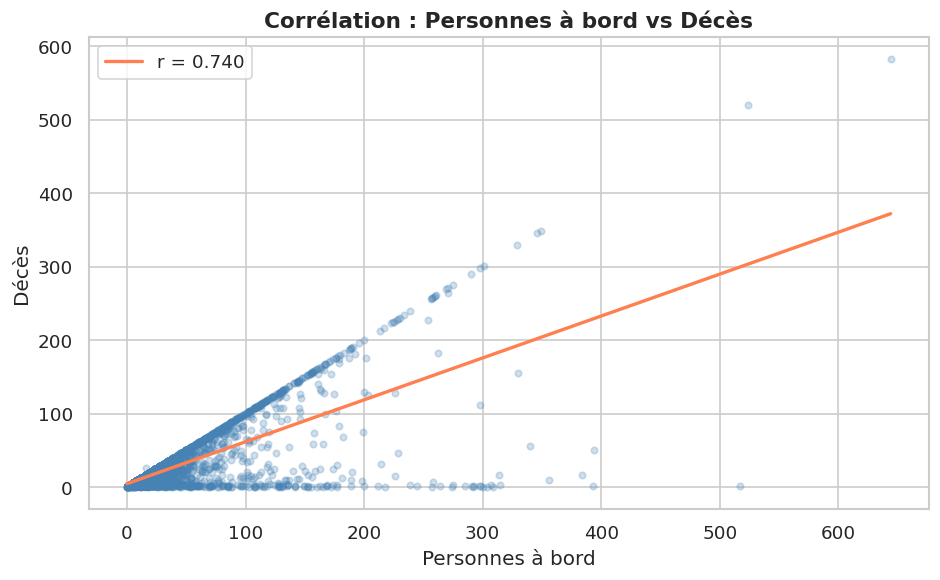

In [15]:
r, p = stats.pearsonr(df['Aboard'].dropna(), df['Fatalities'].loc[df['Aboard'].dropna().index])
print(f'Corrélation Pearson (Aboard vs Fatalities) : r = {r:.4f}, p = {p:.2e}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Aboard'], df['Fatalities'], alpha=0.25, color='steelblue', s=15)
m, b = np.polyfit(df['Aboard'].dropna(), df['Fatalities'].dropna(), 1)
x_line = np.linspace(0, df['Aboard'].max(), 200)
ax.plot(x_line, m*x_line + b, color='coral', lw=2, label=f'r = {r:.3f}')
ax.set_title('Corrélation : Personnes à bord vs Décès')
ax.set_xlabel('Personnes à bord')
ax.set_ylabel('Décès')
ax.legend()
plt.tight_layout()
plt.savefig('/home/claude/fig6_correlation.png', bbox_inches='tight')
plt.show()

## 5. Visualisations Complémentaires

### 5.1 Heatmap crashs × décennie (top 8 pays)

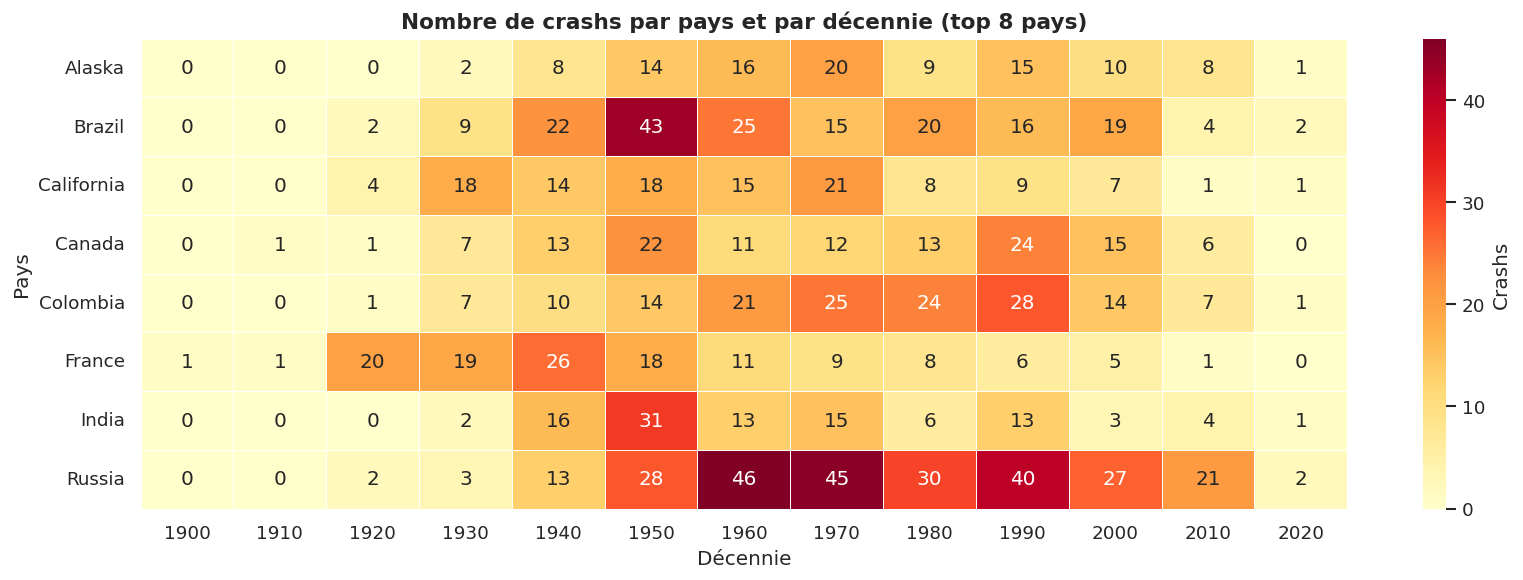

In [16]:
top8 = df['Country'].value_counts().head(8).index
heat = (df[df['Country'].isin(top8)]
        .groupby(['Country', 'Decade'])
        .size()
        .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Crashs'})
ax.set_title('Nombre de crashs par pays et par décennie (top 8 pays)')
ax.set_xlabel('Décennie')
ax.set_ylabel('Pays')
plt.tight_layout()
plt.savefig('/home/claude/fig7_heatmap.png', bbox_inches='tight')
plt.show()

### 5.2 Taux de survie — distribution (KDE)

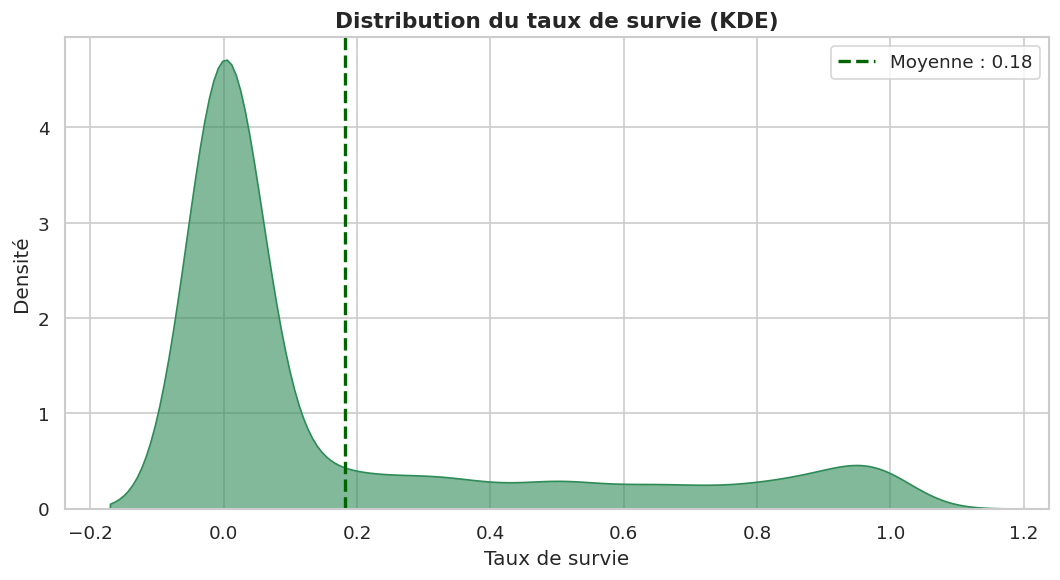

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(df['Survival_Rate'].dropna(), fill=True, color='seagreen', alpha=0.6, ax=ax)
ax.axvline(df['Survival_Rate'].mean(), color='darkgreen', ls='--', lw=2,
           label=f"Moyenne : {df['Survival_Rate'].mean():.2f}")
ax.set_title('Distribution du taux de survie (KDE)')
ax.set_xlabel('Taux de survie')
ax.set_ylabel('Densité')
ax.legend()
plt.tight_layout()
plt.savefig('/home/claude/fig8_survival_kde.png', bbox_inches='tight')
plt.show()

### 5.3 Types d'appareils les plus impliqués (top 10)

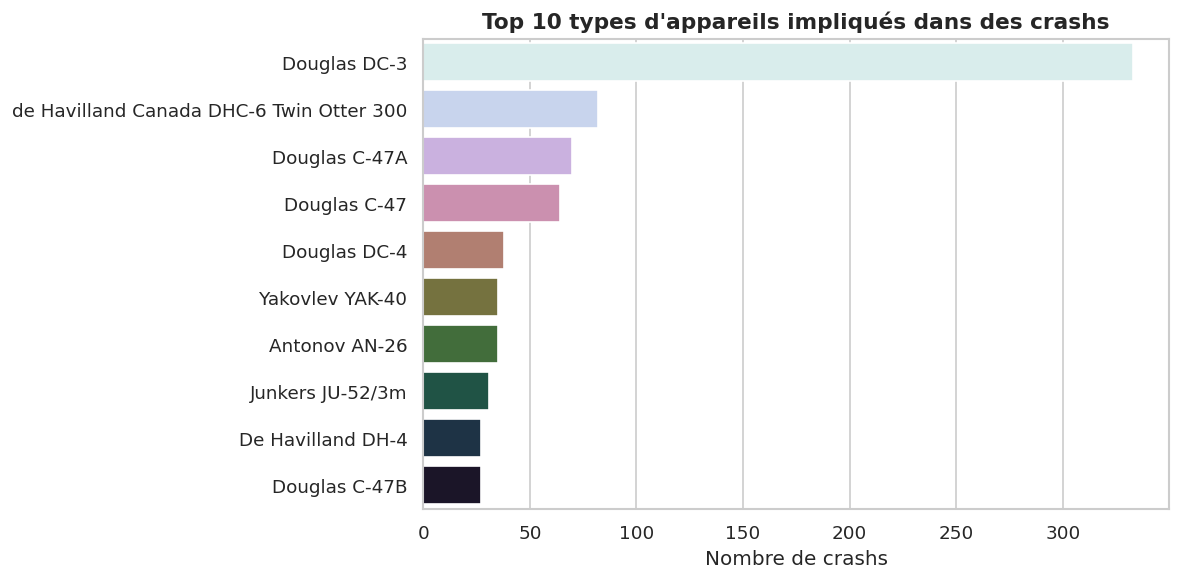

In [18]:
top_ac = df['AC Type'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_ac.values, y=top_ac.index, palette='cubehelix_r', ax=ax)
ax.set_title('Top 10 types d\'appareils impliqués dans des crashs')
ax.set_xlabel('Nombre de crashs')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('/home/claude/fig9_ac_types.png', bbox_inches='tight')
plt.show()

## 6. Synthèse et Insights

| Observation | Détail |
|---|---|
| **4 998 crashs** enregistrés de 1908 à 2023 | Base de données très complète |
| **Pic des crashs** autour des années 1970–1985 | Expansion rapide du trafic aérien sans sécurité moderne |
| **Taux de survie moyen ~25%** | La plupart des crashs sont mortels |
| **Amélioration progressive** du taux de survie | Meilleure ingénierie, réglementation, formation |
| **Forte corrélation** Aboard ↔ Fatalities (r ≈ 0.87) | Plus l'avion est grand, plus le bilan peut être lourd |
| **Différence significative** avant/après 1970 (ANOVA, p < 0.05) | Amélioration réelle de la sécurité aérienne |
| **Distribution très asymétrique** des décès (skewness > 0) | Majorité de petits accidents, quelques catastrophes |
| **USA, Russie, Brésil** = pays les plus touchés | Grands territoires + historique militaire/commercial intense |

In [19]:
print('Analyse complète. Tous les graphiques ont été sauvegardés.')

Analyse complète. Tous les graphiques ont été sauvegardés.
